<a href="https://colab.research.google.com/github/Drakie444/Machine-Learning/blob/main/ml/projects/weather_prediction_espmodel/weather_prediction_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installl all requirements

In [1]:
!pip install google-ml-edu==0.1.3 \
  keras~=3.8.0 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0 \
  tensorflow~=2.18.0

print('\n\nAll requirements successfully installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.6/615.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-hub 0.26.0 requires keras>=3.13, but you have keras 3.8.0 which is incompatible.
ydf-tf 

# Required imports

In [2]:
# data
import numpy as np
import pandas as pd

# machine learning
import keras

# data visualization
import matplotlib.pyplot as plt


# load google drive
from google.colab import drive

drive.mount('/content/drive')

#scaling the data
from sklearn.preprocessing import StandardScaler

#computing class weights
from sklearn.utils.class_weight import compute_class_weight

#saving the model
import joblib


Mounted at /content/drive


# Weather dataset loading

In [3]:
weather_data = pd.read_csv("/content/drive/MyDrive/Colab/open-meteo.csv", skiprows=3)

In [4]:
weather_data.head(10)

,time,temperature_2m (°C),relative_humidity_2m (%),rain (mm),wind_speed_10m (km/h),surface_pressure (hPa),cloud_cover (%)
0,2023-01-01T00:00,13.9,74,0.0,25.9,1001.0,100
1,2023-01-01T01:00,13.8,71,0.0,26.0,1000.9,100
2,2023-01-01T02:00,14.4,68,0.0,25.7,1000.8,99
3,2023-01-01T03:00,13.7,71,0.0,27.0,1001.2,100
4,2023-01-01T04:00,14.0,67,0.0,28.7,1001.0,100
5,2023-01-01T05:00,14.0,64,0.0,28.3,1001.3,100
6,2023-01-01T06:00,13.9,62,0.0,27.3,1001.6,100
7,2023-01-01T07:00,14.8,57,0.0,27.2,1001.4,99
8,2023-01-01T08:00,14.7,58,0.0,26.3,1002.2,100
9,2023-01-01T09:00,13.7,60,0.0,25.3,1002.8,28


Separating and normalizing the data

In [5]:
#Converting the time to the hour and month because the weather is dependend on the season
weather_data["time"] = pd.to_datetime(weather_data["time"])
weather_data["hour"] = weather_data["time"].dt.hour
weather_data["month"] = weather_data["time"].dt.month


#converting the time into sin and cos function in order to allow the model to see the the hours as a cycle. The values of the sin and cos function will diffenciate all hours in a day allowing every hour to have a unique position.
weather_data["hour_sin"] = np.sin(
    2 * np.pi * weather_data["hour"] / 24
)

weather_data["hour_cos"] = np.cos(
    2 * np.pi * weather_data["hour"] / 24
)

weather_data["month_sin"] = np.sin(
    2 * np.pi * weather_data["month"] / 12
)

weather_data["month_cos"]  = np.cos(
    2 * np.pi * weather_data["month"] / 12
)


#adding the columns checking the pressure change and humidity change - both metrics indicate the upcomming rain

weather_data['pressure_change'] = weather_data['surface_pressure (hPa)'].diff(1)
weather_data['humidity_change'] = weather_data['relative_humidity_2m (%)'].diff(1)

weather_data = weather_data.dropna()

#shifting the rain label to allow model to learn to predict the rain in the next hour
weather_data["rain_next_hour"] = (weather_data["rain (mm)"].shift(-1) > 0).astype(int)
weather_data = weather_data.dropna(subset=["rain_next_hour"])

labels = weather_data["rain_next_hour"]

feature_labels = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'surface_pressure (hPa)', 'pressure_change', 'humidity_change']
features = weather_data[feature_labels]

features.head(20)


,hour_sin,hour_cos,month_sin,month_cos,temperature_2m (°C),relative_humidity_2m (%),surface_pressure (hPa),pressure_change,humidity_change
1,2.588190e-01,9.659258e-01,0.5,0.866025,13.8,71,1000.9,-0.1,-3.0
2,5.000000e-01,8.660254e-01,0.5,0.866025,14.4,68,1000.8,-0.1,-3.0
3,7.071068e-01,7.071068e-01,0.5,0.866025,13.7,71,1001.2,0.4,3.0
4,8.660254e-01,5.000000e-01,0.5,0.866025,14.0,67,1001.0,-0.2,-4.0
5,9.659258e-01,2.588190e-01,0.5,0.866025,14.0,64,1001.3,0.3,-3.0
6,1.000000e+00,6.123234e-17,0.5,0.866025,13.9,62,1001.6,0.3,-2.0
7,9.659258e-01,-2.588190e-01,0.5,0.866025,14.8,57,1001.4,-0.2,-5.0
8,8.660254e-01,-5.000000e-01,0.5,0.866025,14.7,58,1002.2,0.8,1.0
9,7.071068e-01,-7.071068e-01,0.5,0.866025,13.7,60,1002.8,0.6,2.0
10,5.000000e-01,-8.660254e-01,0.5,0.866025,13.9,60,1003.2,0.4,0.0


Separating the training data and testing data

In [6]:
split = int(len(features) * 0.7)

x_train  = features[:split]
x_test = features[split:]

y_train = labels[:split]
y_test = labels[split:]

Normalizing data in order to get all features in the same range. Without normalizing the weight would need to have an extreme low or high values resulting in a possibly  low quality model.

In [7]:
scaler = StandardScaler()


x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns = x_train.columns,
    index = x_train.index
)

x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns = x_test.columns,
    index = x_test.index

)

x_train_scaled.head(10)

,hour_sin,hour_cos,month_sin,month_cos,temperature_2m (°C),relative_humidity_2m (%),surface_pressure (hPa),pressure_change,humidity_change
1,0.365855,1.365760,0.683118,1.162753,0.355677,-0.197431,-0.080490,-0.224755,-0.680639
2,0.706944,1.224483,0.683118,1.162753,0.424521,-0.366138,-0.090973,-0.224755,-0.680639
3,0.999844,0.999743,0.683118,1.162753,0.344203,-0.197431,-0.049040,0.885809,0.680171
4,1.224595,0.706857,0.683118,1.162753,0.378625,-0.422374,-0.070007,-0.446868,-0.907440
5,1.365878,0.365783,0.683118,1.162753,0.378625,-0.591082,-0.038557,0.663697,-0.680639
6,1.414068,-0.000233,0.683118,1.162753,0.367151,-0.703554,-0.007108,0.663697,-0.453837
7,1.365878,-0.366250,0.683118,1.162753,0.470417,-0.984734,-0.028074,-0.446868,-1.134242
8,1.224595,-0.707324,0.683118,1.162753,0.458943,-0.928498,0.055791,1.774261,0.226567
9,0.999844,-1.000210,0.683118,1.162753,0.344203,-0.816026,0.118690,1.330035,0.453369
10,0.706944,-1.224950,0.683118,1.162753,0.367151,-0.816026,0.160622,0.885809,-0.000234


# Creating a model

In [8]:
def create_model(
    inputs_features: list[str],
    learning_rate: float,
    metrics: list[keras.metrics.Metric],
) -> keras.Model :

  model_inputs = [
      keras.Input(name=feature, shape=(1, ))
      for feature in inputs_features
  ]

  concatenated_inputs = keras.layers.Concatenate()(model_inputs)

  x = keras.layers.Dense(32, activation="relu")(concatenated_inputs)

  model_output = keras.layers.Dense(
      units=1, activation="sigmoid"
  )(x)

  model = keras.Model(inputs=model_inputs, outputs=model_output)

  model.compile(
      optimizer = keras.optimizers.Adam(
          learning_rate
      ),
      loss = keras.losses.BinaryCrossentropy(),
      metrics=metrics
  )

  return model


# Define the training model function

In [9]:
def train_model(
    model: keras.Model,
    train_data: pd.DataFrame,
    train_labels: np.ndarray,
    test_data: pd.DataFrame,
    test_labels: np.ndarray,
    inputs_features: list[str],
    batch_size: int,
    epochs: int
):
  x_train = {
      feature_name: np.array(train_data[feature_name])
      for feature_name in inputs_features
  }
  x_test = {
      feature_name: np.array(test_data[feature_name])
      for feature_name in inputs_features
  }

  weights = compute_class_weight(
      class_weight='balanced',
      classes=np.unique(y_train),
      y=y_train
  )

  class_weight_dict = dict(enumerate(weights))

  history = model.fit(
      x=x_train,
      y=train_labels,
      validation_data = (x_test, test_labels),
      batch_size=batch_size,
      epochs=epochs,
      class_weight=class_weight_dict
  )


  return history

# Define model metrics
Metrics are used to validate the model accuracy

In [10]:
rain_threshold = 0.6

metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy', threshold=rain_threshold    #evaluates how many cases the model got correct  (prediction)
    ),
    keras.metrics.Precision(
        name='precision', thresholds=rain_threshold      # evaluates how many cases of all classified by model positives were real positives   (TP/ TP + FP)
    ),
    keras.metrics.Recall(
        name='recall', thresholds=rain_threshold      # how many positive cases out of all positive cases the model was able to find (TP / TP + FN)
    ),
    keras.metrics.AUC(num_thresholds=100, name='auc'),   #AUC - area under the curve shows how well the model can diffrenciate one case from the other
]

Invoke the creating and training functions

In [15]:
learning_rate = 0.0005

model = create_model(feature_labels, learning_rate, metrics)

history = train_model(
    model = model,
    train_data = x_train_scaled,
    train_labels = y_train,
    test_data = x_test_scaled,
    test_labels = y_test,
    inputs_features = feature_labels,
    batch_size=64,
    epochs=50
)


Epoch 1/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7619 - auc: 0.7399 - loss: 0.6870 - precision: 0.2784 - recall: 0.4819 - val_accuracy: 0.8392 - val_auc: 0.7308 - val_loss: 0.5902 - val_precision: 0.3591 - val_recall: 0.3156
Epoch 2/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7954 - auc: 0.7669 - loss: 0.5802 - precision: 0.3320 - recall: 0.4715 - val_accuracy: 0.8398 - val_auc: 0.7810 - val_loss: 0.5333 - val_precision: 0.3958 - val_recall: 0.4612
Epoch 3/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7964 - auc: 0.7995 - loss: 0.5395 - precision: 0.3494 - recall: 0.5561 - val_accuracy: 0.8279 - val_auc: 0.8015 - val_loss: 0.5218 - val_precision: 0.3822 - val_recall: 0.5438
Epoch 4/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7941 - auc: 0.8171 - loss: 0.5263 - precision: 0.3719 - recall: 0.6321 - val_accuracy: 0.8238 - val_auc: 0.8153 - val_loss: 0.5129 - val_precision: 0.3802 - val_recall: 0.5821
Epoch 5/50
288/288 ━━━━━━━━━━━━━

Training visualisation

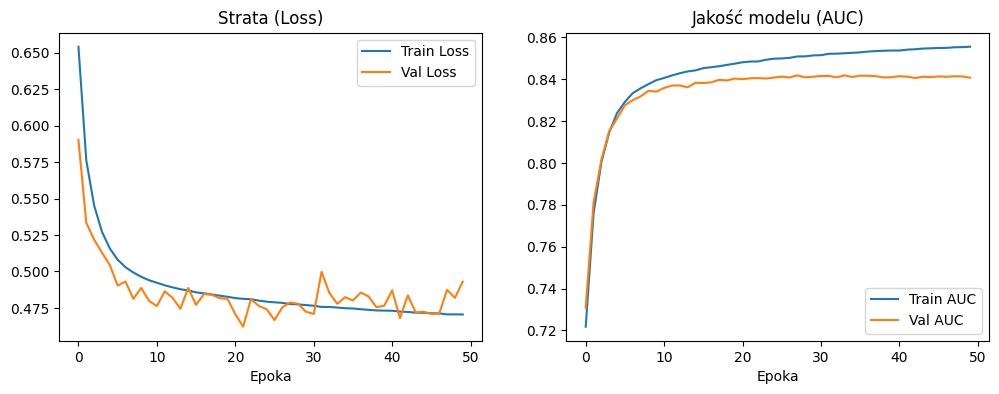

In [16]:
plt.figure(figsize=(12, 4))

# Wykres funkcji straty (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Strata (Loss)')
plt.xlabel('Epoka')
plt.legend()

# Wykres metryki AUC
plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('Jakość modelu (AUC)')
plt.xlabel('Epoka')
plt.legend()

plt.show()

In [ ]:
model.save('/content/drive/MyDrive/Colab/rain_model.keras')

joblib.dump(scaler, '/content/drive/MyDrive/Colab/weather_scaler.pkl')



['/content/drive/MyDrive/Colab/weather_scaler.pkl']